# SIDM Half-Light Radius Mass Function

Samples halos from the analytic CDM HMF, transforms to SIDM using the parametricSIDM
basic approach (Yang+2023), and compares the enclosed mass function M(<r₁/₂) against
observed Local Group dSphs and alternative dark matter models.

**Key choices:**
- HMF: tinker08 + colossus CDF sampling
- NFW params: colossus NFWProfile (exact h-handling)
- c(M): Diemer+Joyce 2019, 0.15 dex scatter
- r₁/₂: 37×(Rvir/10)^1.07 pc, 0.63 dex scatter, clipped to 20–3000 pc
- σ_eff: direct double integral, v_upper = 10×max(vmax,w)
- M_enc: tanh(r/rc) × M_NFW(evolved params)
- z_form: quadratic fit from Giocoli+2011

In [1]:
# ── Cell 1: Imports ────────────────────────────────────────────────────────
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import dblquad
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d
from scipy.stats import chi2 as chi2_dist
from tqdm.auto import tqdm

from colossus.cosmology import cosmology
from colossus.lss import mass_function
from colossus.halo import concentration as col_conc
from colossus.halo import profile_nfw as col_nfw

PSIDM_ROOT = os.path.expanduser('./parametricSIDM')
if PSIDM_ROOT not in sys.path:
    sys.path.insert(0, PSIDM_ROOT)
from parametricCoredDZ import frho, rhost, rst, rct, MtotNFW, rho200c, GG

print('All imports OK')

All imports OK


In [2]:
# ── Cell 2: Parameters ────────────────────────────────────────────────────
COSMO_NAME    = 'planck18'
MDEF          = '200c'
N_HALOS       = 2000
M_LOW         = 1e8
M_HIGH        = 1e11
REDSHIFT      = 0.0
C_SCATTER_DEX = 0.15

# Half-light radius: r_half [pc] = A_HLR * (Rvir[kpc]/10)^N_HLR, clipped
A_HLR         = 37.0    # pc at Rvir=10 kpc
N_HLR         = 1.07
SIGMA_LOGR    = 0.63    # dex scatter
R_HALF_MIN_PC = 20.0
R_HALF_MAX_PC = 3000.0

TAU_MAX = 1.1

np.random.seed(42)

# SIDM models: label -> (sigma0 [cm2/g], w [km/s])
SIDM_MODELS = {
    r'$\sigma_0=147,\,w=70$':  (147.1, 70.0),
    r'$\sigma_0=500,\,w=50$':  (500.0, 50.0),
}

In [3]:
# ── Cell 3: Cosmology + physical functions ─────────────────────────────────
cosmo = cosmology.setCosmology(COSMO_NAME)
h = cosmo.H0 / 100.0
print(f'h = {h:.4f}')

def sigmaeff(vmax, sigma0, w):
    """Thermally-averaged effective cross section [cm2/g]."""
    veff    = 1.1 * vmax / np.sqrt(3)
    v_upper = 10.0 * max(vmax, w)
    diff    = lambda theta, v: sigma0 * w**4 / (2*(w**2 + v**2*np.sin(theta/2)**2)**2)
    fup   = lambda v, theta: v**7 * np.sin(theta)**3 * np.exp(-v**2/(4*veff**2)) * diff(theta, v)
    fdown = lambda v, theta: v**7 * np.sin(theta)**3 * np.exp(-v**2/(4*veff**2))
    termu = dblquad(fup,   0, np.pi, 0, v_upper, epsrel=1e-4)[0]
    termd = dblquad(fdown, 0, np.pi, 0, v_upper, epsrel=1e-4)[0]
    return 2 * termu / termd

def build_sigmaeff_interp(sigma0, w, vmax_min=1.0, vmax_max=500.0, n_pts=60):
    """Pre-tabulate sigmaeff on a log-spaced Vmax grid."""
    vmax_grid = np.logspace(np.log10(vmax_min), np.log10(vmax_max), n_pts)
    print(f'  Tabulating sigma_eff (sigma0={sigma0}, w={w})...')
    se_grid = np.array([sigmaeff(v, sigma0, w) for v in tqdm(vmax_grid, leave=False)])
    return interp1d(np.log10(vmax_grid), se_grid, kind='cubic',
                    fill_value=(se_grid[0], se_grid[-1]), bounds_error=False)

def tc_dmo(sigma_eff_val, rhos, rs):
    """Core-collapse time [Gyr]. Yang+2023 Eq.(2.2), C=0.75."""
    return (150.0/0.75) / (sigma_eff_val * 2.09e-10 * rhos * rs) / np.sqrt(4*np.pi*GG*rhos)

def formation_redshift(M_msun):
    """Median formation redshift, quadratic fit (Giocoli+2011)."""
    x = np.log10(M_msun / 1e10)
    return -0.0064*x**2 - 0.1043*x + 1.4807

def tlb(z):
    """Lookback time [Gyr] from parametricC4.py."""
    return (13.647247606199668
            - 11.020482589612016
            * np.log(1.5800327517186143/(1+z)**1.5
                     + np.sqrt(1.0 + 2.4965034965034962/(1+z)**3)))

def halo_age(M_msun):
    return tlb(formation_redshift(M_msun))

def sidm_enclosed_mass(rhos0, rs0, tau, r_eval):
    """M_enc(<r_eval) using tanh approximation with Yang+2023 evolved params."""
    if r_eval <= 0: return 0.0
    if tau < 0.01:  return MtotNFW(r_eval, rhos0, rs0)
    rhos_t = rhost(tau, rhos0, rs0)
    rs_t   = rst(tau,  rhos0, rs0)
    rc_t   = rct(tau,  rhos0, rs0)
    M_nfw  = MtotNFW(r_eval, rhos_t, rs_t)
    if rc_t <= 0: return M_nfw
    return np.tanh(r_eval / rc_t) * M_nfw

print('Functions defined.')

h = 0.6766
Functions defined.


In [4]:
# ── Cell 4: Sample halo masses from tinker08 HMF ──────────────────────────
def build_mass_cdf(m_low, m_high, z, n_table=400):
    log_m   = np.linspace(np.log10(m_low), np.log10(m_high), n_table)
    m_arr   = 10.0**log_m
    mf_vals = mass_function.massFunction(m_arr*h, z, mdef=MDEF, model='tinker08', q_out='dndlnM')
    dlnm    = np.diff(np.log(m_arr))
    cdf     = np.concatenate([[0.0], np.cumsum(0.5*(mf_vals[:-1]+mf_vals[1:])*dlnm)])
    cdf    /= cdf[-1]
    return m_arr, cdf

def sample_masses(n, m_low, m_high, z):
    m_arr, cdf = build_mass_cdf(m_low, m_high, z)
    return 10.0**np.interp(np.random.uniform(0, 1, n), cdf, np.log10(m_arr))

m_vir = sample_masses(N_HALOS, M_LOW, M_HIGH, REDSHIFT)
print(f'Sampled {N_HALOS} halos, log10(M200c) in [{np.log10(m_vir.min()):.2f}, {np.log10(m_vir.max()):.2f}]')

Sampled 2000 halos, log10(M200c) in [8.00, 10.93]


In [5]:
# ── Cell 5: Concentration + NFW structural parameters ─────────────────────
c_med    = np.array([col_conc.concentration(mi*h, MDEF, REDSHIFT, model='diemer19') for mi in m_vir])
c_arr    = c_med * 10.0**np.random.normal(0.0, C_SCATTER_DEX, N_HALOS)

rho_s_arr = np.zeros(N_HALOS)
r_s_arr   = np.zeros(N_HALOS)
r_vir_arr = np.zeros(N_HALOS)   # Bryan-Norman Rvir [kpc]
vmax_arr  = np.zeros(N_HALOS)

for i in range(N_HALOS):
    prof = col_nfw.NFWProfile(M=m_vir[i]*h, c=c_arr[i], z=REDSHIFT, mdef=MDEF)
    rhos_h, rs_h  = prof.getParameterArray()
    rho_s_arr[i]  = rhos_h * h**2      # M_sun/kpc3
    r_s_arr[i]    = rs_h   / h          # kpc
    r_vir_h, _    = prof.RMDelta(z=REDSHIFT, mdef='vir')
    r_vir_arr[i]  = r_vir_h / h         # kpc
    vmax_arr[i]   = prof.Vmax()[0]      # km/s

R_mw = col_nfw.NFWProfile(M=1e12*h, c=10, z=0, mdef='200c').RMDelta(z=0, mdef='200c')[0] / h
print(f'Sanity: R_200c for 1e12 Msun, c=10 = {R_mw:.0f} kpc  (expect ~200 kpc)')
print(f'Vmax range [km/s]: {vmax_arr.min():.1f} – {vmax_arr.max():.1f}')

Sanity: R_200c for 1e12 Msun, c=10 = 211 kpc  (expect ~200 kpc)
Vmax range [km/s]: 7.5 – 66.5


In [6]:
# ── Cell 6: Half-light radii ───────────────────────────────────────────────
r_half_pc = (
    A_HLR
    * (r_vir_arr / 10.0)**N_HLR
    * 10.0**np.random.normal(0.0, SIGMA_LOGR, N_HALOS)
)
r_half_pc = np.clip(r_half_pc, R_HALF_MIN_PC, R_HALF_MAX_PC)
r_half    = r_half_pc / 1e3   # kpc

print(f'r_half range [pc]: {r_half_pc.min():.1f} – {r_half_pc.max():.1f}')
print(f'Median r_half [pc]: {np.median(r_half_pc):.1f}')
print(f'Fraction at lower bound ({R_HALF_MIN_PC:.0f} pc): {(r_half_pc==R_HALF_MIN_PC).mean():.3f}')

r_half range [pc]: 20.0 – 3000.0
Median r_half [pc]: 67.3
Fraction at lower bound (20 pc): 0.198


In [7]:
# ── Cell 7: CDM enclosed masses ────────────────────────────────────────────
m_half_cdm = np.array([MtotNFW(r_half[i], rho_s_arr[i], r_s_arr[i]) for i in range(N_HALOS)])
good_cdm   = np.isfinite(m_half_cdm) & (m_half_cdm > 0)
print(f'Valid CDM halos: {good_cdm.sum()} / {N_HALOS}')

Valid CDM halos: 2000 / 2000


In [8]:
# ── Cell 8: Run SIDM models ────────────────────────────────────────────────
results = {}

for label, (sigma0, w) in SIDM_MODELS.items():
    print(f'\n=== {label} ===')
    se_interp = build_sigmaeff_interp(sigma0, w)

    tau_i = np.zeros(N_HALOS)
    se_i  = np.zeros(N_HALOS)
    tc_i  = np.zeros(N_HALOS)

    for i in range(N_HALOS):
        se         = float(se_interp(np.log10(vmax_arr[i])))
        tc         = tc_dmo(se, rho_s_arr[i], r_s_arr[i])
        t_age      = halo_age(m_vir[i])
        se_i[i]    = se
        tc_i[i]    = tc
        tau_i[i]   = min(t_age / tc, TAU_MAX)

    m_sidm_i = np.full(N_HALOS, np.nan)
    for i in tqdm(range(N_HALOS), desc='  M_enc'):
        try:
            m_sidm_i[i] = sidm_enclosed_mass(rho_s_arr[i], r_s_arr[i], tau_i[i], r_half[i])
        except Exception:
            pass

    good = np.isfinite(m_sidm_i) & (m_sidm_i > 0)
    results[label] = dict(tau=tau_i, sigma_eff=se_i, tc=tc_i, m_half=m_sidm_i, good=good)
    print(f'  sigma_eff: {se_i.min():.1f}–{se_i.max():.1f} cm2/g')
    print(f'  tau:       {tau_i.min():.4f}–{tau_i.max():.3f}')
    print(f'  Collapsed (tau=1.1): {(tau_i>=TAU_MAX).sum()}/{N_HALOS}')


=== $\sigma_0=147,\,w=70$ ===
  Tabulating sigma_eff (sigma0=147.1, w=70.0)...


  0%|          | 0/60 [00:00<?, ?it/s]

  M_enc:   0%|          | 0/2000 [00:00<?, ?it/s]

  sigma_eff: 19.8–137.1 cm2/g
  tau:       0.0284–1.100
  Collapsed (tau=1.1): 691/2000

=== $\sigma_0=500,\,w=50$ ===
  Tabulating sigma_eff (sigma0=500.0, w=50.0)...


  0%|          | 0/60 [00:00<?, ?it/s]

  M_enc:   0%|          | 0/2000 [00:00<?, ?it/s]

  sigma_eff: 32.0–438.0 cm2/g
  tau:       0.0460–1.100
  Collapsed (tau=1.1): 1511/2000


In [9]:
# ── Cell 9: Load observed dSphs ────────────────────────────────────────────
df = pd.read_csv('./dsph_wolf_mass_forecasts.csv', index_col=0)
df = df[df['M_dynamical_wolf'].notna()].copy()
df['M_wolf']   = df['M_dynamical_wolf'].astype(float)
df['M_err']    = df['M_err'].astype(float)
df['frac_err'] = df['frac_M_err'].astype(float)
df['D_kpc']    = df['D'].astype(float)
df['MV']       = df['M_V'].astype(float)
df_rel = df[df['frac_err'] < 1.0].copy()
print(f'Reliable dSphs (frac_err < 1): {len(df_rel)}')

# ── Load external DM model mass functions ────────────────────────────────
def load_mf(path):
    data = np.loadtxt(path, delimiter=',', comments='#')
    return data[:, 0], data[:, 1]   # mass [Msun], N(>M)

cdm_ext_m, cdm_ext_n = load_mf('./cdm_data.txt')
wdm7_m,    wdm7_n    = load_mf('./wdm7_data.txt')
bump1_m,   bump1_n   = load_mf('./bump1_data.txt')
bump2_m,   bump2_n   = load_mf('./bump3_data.txt')
print('External MF data loaded.')

Reliable dSphs (frac_err < 1): 65
External MF data loaded.


In [28]:
# ── Cell 10: Observed histogram + Rubin setup ──────────────────────────────
log_m_lo, log_m_hi = 5.5, 8.8
n_bins   = 9
bins     = np.logspace(log_m_lo, log_m_hi, n_bins + 1)
bin_cen  = np.sqrt(bins[:-1] * bins[1:])
alpha    = 0.317   # 1-sigma

def gehrels(counts):
    hi = 0.5*chi2_dist.ppf(1-alpha/2, 2*(counts+1)) - counts
    lo = counts - 0.5*chi2_dist.ppf(alpha/2, 2*np.maximum(counts, 1))
    return np.where(counts==0, 0, lo), hi

# Raw observed counts
obs_counts_raw, _ = np.histogram(df_rel['M_wolf'].values, bins=bins)
N_OBS_RAW = obs_counts_raw.sum()

# Measurement error via bootstrap
n_boot = 500
rng = np.random.default_rng(42)
boot_counts = np.zeros((n_boot, n_bins))
for b in range(n_boot):
    M_p = df_rel['M_wolf'].values * 10**rng.normal(0, df_rel['frac_err'].values/np.log(10), len(df_rel))
    boot_counts[b], _ = np.histogram(M_p, bins=bins)
meas_lo = obs_counts_raw - np.percentile(boot_counts, 16, axis=0)
meas_hi = np.percentile(boot_counts, 84, axis=0) - obs_counts_raw

pois_lo, pois_hi = gehrels(obs_counts_raw.astype(float))
err_lo_tot = np.sqrt(pois_lo**2 + meas_lo**2)
err_hi_tot = np.sqrt(pois_hi**2 + meas_hi**2)

# ── Updated Rubin forecast for full 800 kpc volume ───────────────────────
#
# Current known with reliable kinematics (frac_err < 1): 62
#
# Rubin additions by population:
#   MW satellites (d < 300 kpc):
#     Tsiane+2025: 89 total detectable, ~35 already known in sample → +54 new
#   M31 satellites (d ~770 kpc):
#     PAndAS found ~35; Rubin southern sky opens comparable ultra-faint census → +30-50 new
#   Isolated LG dwarfs (300-800 kpc):
#     SOLO survey: ~16 known within 1 Mpc; Rubin resolves stellar pops
#     to ~500 kpc for M_V < -5 systems → +10-20 new
#
# Conservative total: 62 + 54 + 30 + 10 = ~156
# Optimistic total:   62 + 54 + 50 + 20 = ~186
# Central estimate:   ~170

N_RUBIN_LO  = 150
N_RUBIN_MID = 170
N_RUBIN_HI  = 200

print(f'Updated Rubin forecast for d < 800 kpc:')
print(f'  Current reliable sample:     {N_OBS_RAW}')
print(f'  Rubin central estimate:      {N_RUBIN_MID}')
print(f'  Range:                       {N_RUBIN_LO}–{N_RUBIN_HI}')
print(f'  Improvement factor:          {N_RUBIN_MID/N_OBS_RAW:.1f}x')
print()
print(f'Breakdown of Rubin new discoveries:')
print(f'  New MW ultra-faints (Tsiane+2025):    ~54')
print(f'  New M31 ultra-faints (Rubin+PAndAS):  ~30-50')
print(f'  New isolated LG dwarfs (SOLO+Rubin):  ~10-20')
print(f'  Total new:                            ~94-124')

# Recompute Rubin band and error arrays with updated numbers
frac_per_bin  = obs_counts_raw.astype(float) / N_OBS_RAW
rubin_band_lo = frac_per_bin*N_RUBIN_LO - gehrels(frac_per_bin*N_RUBIN_LO)[0]
rubin_band_hi = frac_per_bin*N_RUBIN_HI + gehrels(frac_per_bin*N_RUBIN_HI)[1]

Updated Rubin forecast for d < 800 kpc:
  Current reliable sample:     62
  Rubin central estimate:      170
  Range:                       150–200
  Improvement factor:          2.7x

Breakdown of Rubin new discoveries:
  New MW ultra-faints (Tsiane+2025):    ~54
  New M31 ultra-faints (Rubin+PAndAS):  ~30-50
  New isolated LG dwarfs (SOLO+Rubin):  ~10-20
  Total new:                            ~94-124


In [29]:
# ── Cell 11: Normalisation helpers ────────────────────────────────────────
def normalise_cdf(m_arr, n_arr, N_target, bins):
    """Convert N(>M) to binned histogram normalised to N_target."""
    interp  = interp1d(np.log10(m_arr), n_arr,
                       bounds_error=False, fill_value=(n_arr[0], 0.0))
    counts  = np.maximum(interp(np.log10(bins[:-1])) - interp(np.log10(bins[1:])), 0)
    total   = counts.sum()
    if total > 0: counts = counts * N_target / total
    return gaussian_filter1d(counts.astype(float), sigma=0.8)

def normalise_model(m_half_arr, good_mask, N_target, bins):
    """Histogram model M_enc values normalised to N_target."""
    m_in   = m_half_arr[good_mask]
    counts, _ = np.histogram(m_in, bins=bins)
    total  = counts.sum()
    if total > 0: counts = counts.astype(float) * N_target / total
    return gaussian_filter1d(counts.astype(float), sigma=0.8)

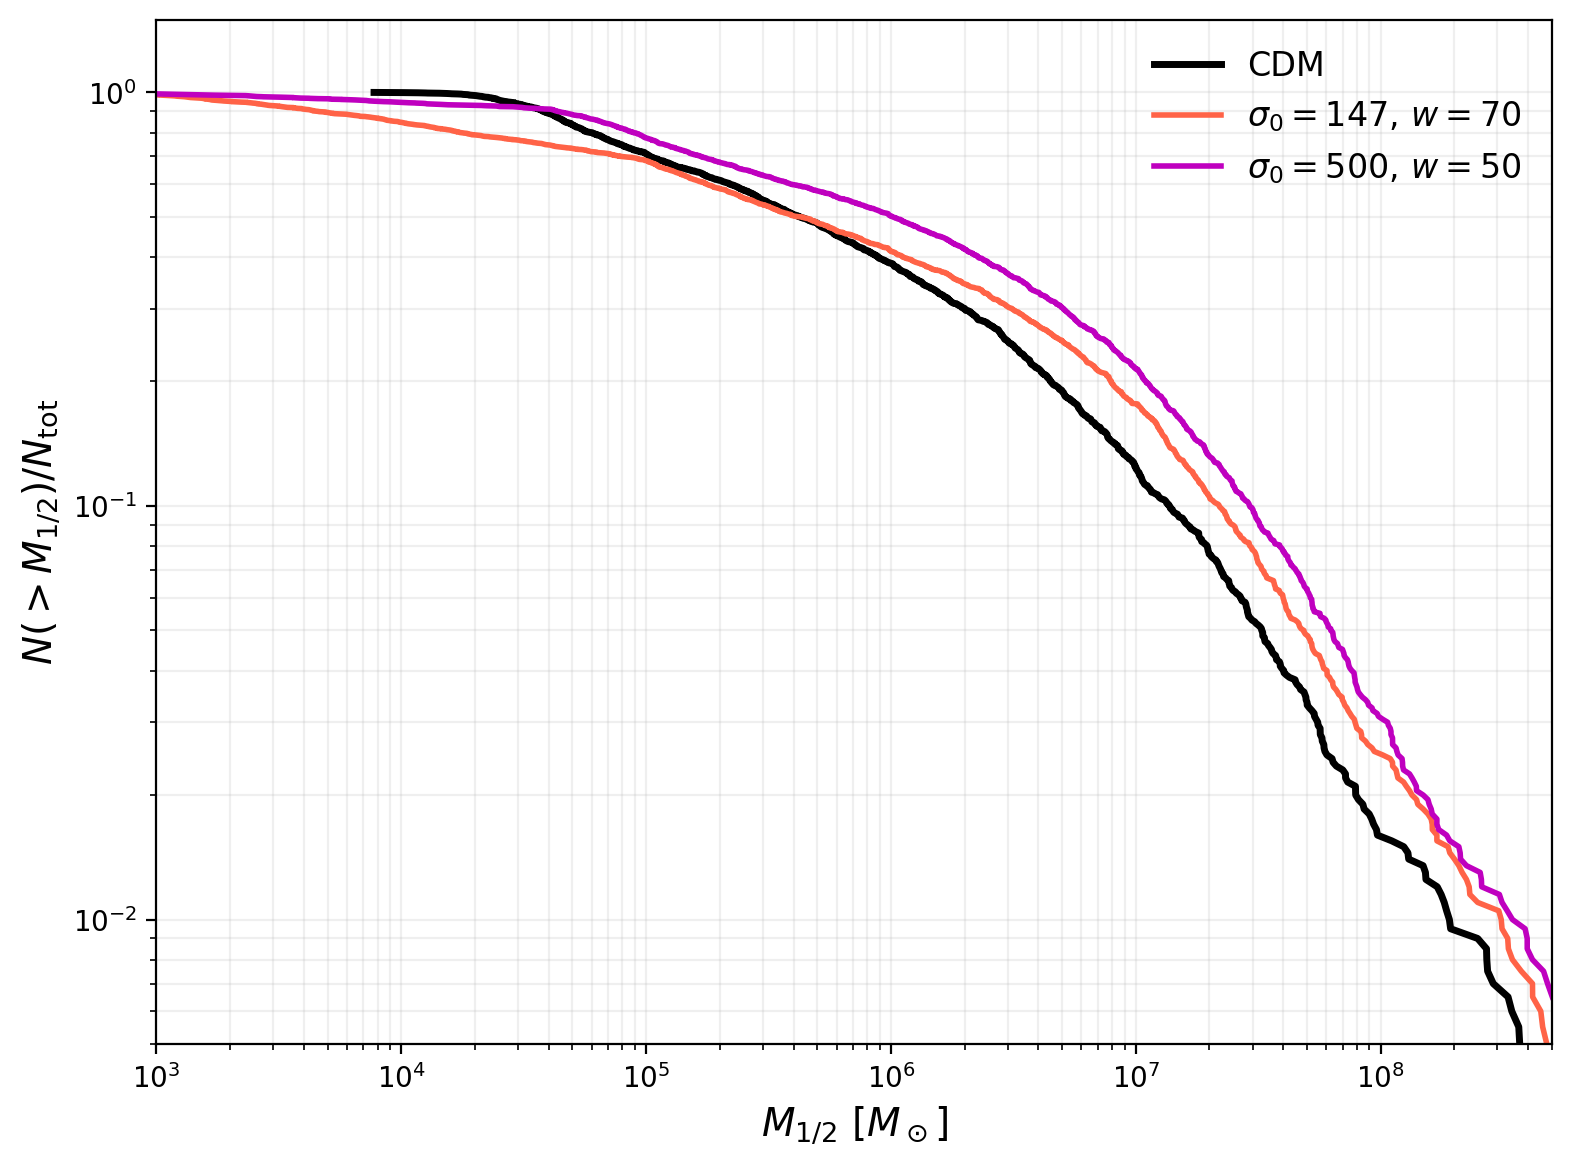

In [30]:
# ── Cell 12: Plot 1 — N(>M) cumulative MF ────────────────────────────────
%config InlineBackend.figure_format = 'retina'
SIDM_COLORS = ['tomato', 'm']

fig, ax = plt.subplots(figsize=(8, 6))

m_sorted_cdm = np.sort(m_half_cdm[good_cdm])
ax.plot(m_sorted_cdm, np.arange(len(m_sorted_cdm), 0, -1)/N_HALOS,
        'k-', lw=2.5, label='CDM')

for (label, res), color in zip(results.items(), SIDM_COLORS):
    m_s = np.sort(res['m_half'][res['good']])
    ax.plot(m_s, np.arange(len(m_s), 0, -1)/N_HALOS, lw=2, color=color, label=label)

ax.set_xlim(1e3, 5e8)
ax.set_ylim(5e-3, 1.5)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$M_{1/2}~[M_\odot]$', fontsize=14)
ax.set_ylabel(r'$N(>M_{1/2})/N_{\rm tot}$', fontsize=14)
ax.legend(fontsize=12, frameon=False)
ax.grid(True, alpha=0.2, which='both')
fig.tight_layout()
plt.savefig('plot1_cumulative_mf.pdf', dpi=150, bbox_inches='tight')
plt.show()

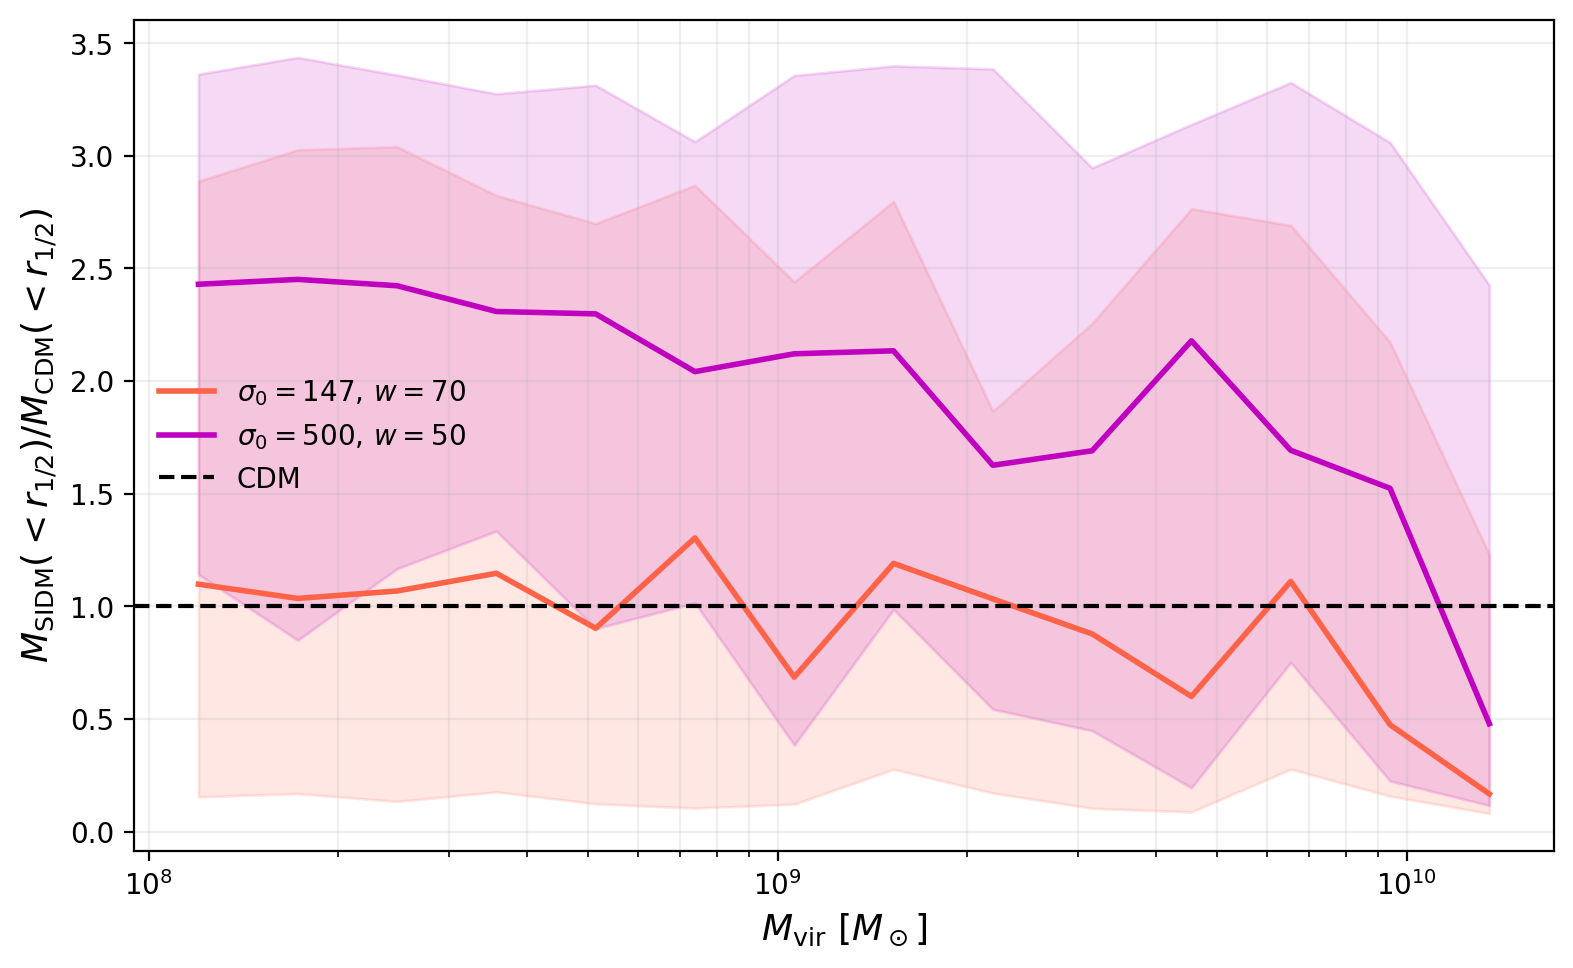

In [31]:
# ── Cell 13: Plot 2 — M_enc/M_CDM ratio vs M_vir ─────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

log_mvir_bins = np.linspace(np.log10(M_LOW), np.log10(M_HIGH), 20)
bin_cens_m    = 0.5 * (log_mvir_bins[:-1] + log_mvir_bins[1:])

for (label, res), color in zip(results.items(), SIDM_COLORS):
    good  = res['good'] & good_cdm
    ratio = res['m_half'][good] / m_half_cdm[good]
    logM  = np.log10(m_vir[good])
    meds, p16, p84 = [], [], []
    for j in range(len(log_mvir_bins)-1):
        mask = (logM >= log_mvir_bins[j]) & (logM < log_mvir_bins[j+1])
        if mask.sum() > 5:
            meds.append(np.median(ratio[mask]))
            p16.append(np.percentile(ratio[mask], 16))
            p84.append(np.percentile(ratio[mask], 84))
        else:
            meds.append(np.nan); p16.append(np.nan); p84.append(np.nan)
    meds, p16, p84 = np.array(meds), np.array(p16), np.array(p84)
    m_plot = 10**bin_cens_m
    ax.plot(m_plot, meds, color=color, lw=2, label=label)
    ax.fill_between(m_plot, p16, p84, color=color, alpha=0.15)

ax.axhline(1.0, color='black', ls='--', lw=1.5, label='CDM')
ax.set_xscale('log')
ax.set_xlabel(r'$M_{\rm vir}~[M_\odot]$', fontsize=13)
ax.set_ylabel(r'$M_{\rm SIDM}(<r_{1/2})/M_{\rm CDM}(<r_{1/2})$', fontsize=13)
ax.legend(fontsize=10, frameon=False)
ax.grid(True, alpha=0.2, which='both')
fig.tight_layout()
plt.savefig('plot2_mass_ratio.pdf', dpi=150, bbox_inches='tight')
plt.show()

N_LIT (existing reliable kinematics): 58
N_RUBIN_MID (SpecS5 full sample):     170
Error bar ratio (lit/SpecS5):         1.71x

  Bin [Msun]   N/bin (plot)   Lit err    S5 err   ratio
-------------------------------------------------------
    4.82e+05           21.9      9.57      5.20    1.84x
    1.12e+06           21.9      9.57      5.20    1.84x
    2.61e+06           21.9      9.57      5.20    1.84x
    6.07e+06           30.2     10.95      6.01    1.82x
    1.41e+07           24.7     10.06      5.49    1.83x
    3.29e+07           24.7     10.06      5.49    1.83x
    7.64e+07           13.7      7.91      4.23    1.87x
    1.78e+08           11.0      7.26      3.84    1.89x
    4.14e+08            0.0      2.70      0.92    2.93x


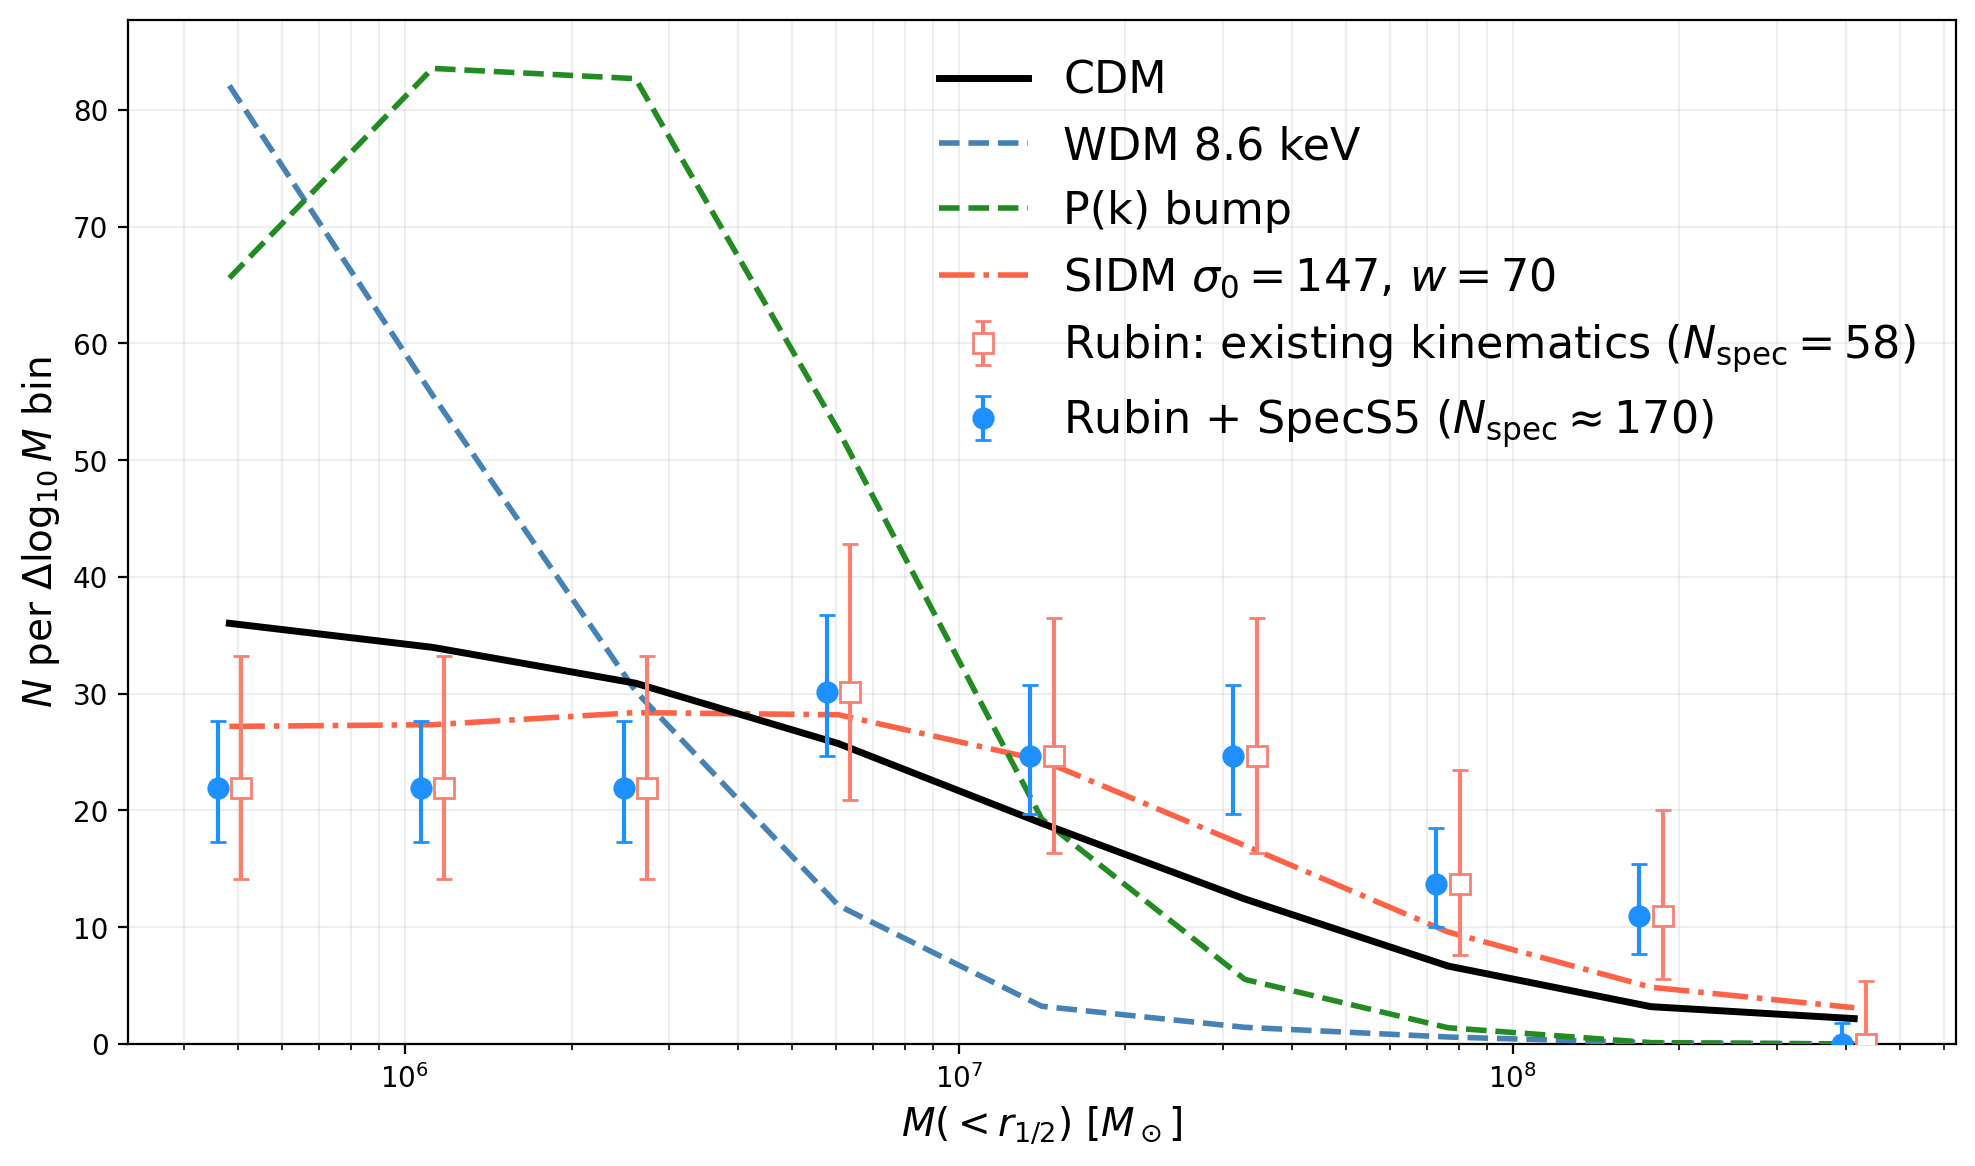

In [36]:
# ── Cell 14: Plot 3 — Rubin forecast vs models ────────────────────────────
# Both scenarios show the same y-values (normalised to N_RUBIN_MID).
# Error bars differ only in the number of galaxies with kinematics:
#   Rubin only:     Poisson based on N_LIT  → larger errors  (ratio √(N_RUBIN/N_LIT))
#   Rubin + SpecS5: Poisson based on N_RUBIN_MID → smaller errors

from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d

# ── Load literature sample to get N_LIT ───────────────────────────────────
df_lit     = pd.read_csv('./dsph_wolf_mass_lit.csv', index_col=0)
df_lit     = df_lit[df_lit['M_dynamical_wolf'].notna()].copy()
df_lit['M_wolf']   = df_lit['M_dynamical_wolf'].astype(float)
df_lit['frac_err'] = df_lit['frac_M_err'].astype(float)
df_lit_rel = df_lit[df_lit['frac_err'] < 1.0].copy()
N_LIT      = len(df_lit_rel)
print(f'N_LIT (existing reliable kinematics): {N_LIT}')
print(f'N_RUBIN_MID (SpecS5 full sample):     {N_RUBIN_MID}')
print(f'Error bar ratio (lit/SpecS5):         {np.sqrt(N_RUBIN_MID/N_LIT):.2f}x')

# ── Shared y-values: both normalised to N_RUBIN_MID ───────────────────────
rubin_counts_plot = obs_counts_raw.astype(float) * N_RUBIN_MID / N_OBS_RAW

# ── Rubin-only errors: Poisson based on N_LIT galaxies ────────────────────
# Compute Poisson on the N_LIT-equivalent counts, then scale back up
rubin_counts_lit_equiv   = rubin_counts_plot * N_LIT / N_RUBIN_MID
pois_lo_lit, pois_hi_lit = gehrels(rubin_counts_lit_equiv)
scale_up                 = N_RUBIN_MID / N_LIT
err_lo_lit_rubin         = pois_lo_lit * scale_up
err_hi_lit_rubin         = pois_hi_lit * scale_up

# ── Rubin + SpecS5 errors: Poisson based on N_RUBIN_MID galaxies ──────────
pois_lo_s5, pois_hi_s5 = gehrels(rubin_counts_plot)
err_lo_s5_rubin         = pois_lo_s5.copy()
err_hi_s5_rubin         = pois_hi_s5.copy()

# ── Print comparison ───────────────────────────────────────────────────────
print(f'\n{"Bin [Msun]":>12}  {"N/bin (plot)":>13}  {"Lit err":>8}  {"S5 err":>8}  {"ratio":>6}')
print('-' * 55)
for j in range(n_bins):
    e_l = 0.5*(err_lo_lit_rubin[j] + err_hi_lit_rubin[j])
    e_s = 0.5*(err_lo_s5_rubin[j]  + err_hi_s5_rubin[j])
    print(f'{bin_cen[j]:>12.2e}  {rubin_counts_plot[j]:>13.1f}  '
          f'{e_l:>8.2f}  {e_s:>8.2f}  {e_l/e_s if e_s>0 else 0:>6.2f}x')

# ── External model normalisation ──────────────────────────────────────────
def cdf_to_counts(m_arr, n_arr, bins):
    interp_fn = interp1d(np.log10(m_arr), n_arr,
                         bounds_error=False, fill_value=(n_arr[0], 0.0))
    return np.maximum(
        interp_fn(np.log10(bins[:-1])) - interp_fn(np.log10(bins[1:])), 0
    ).astype(float)

ext_cdm_counts = cdf_to_counts(cdm_ext_m, cdm_ext_n, bins)
ext_scale      = N_RUBIN_MID / ext_cdm_counts.sum()
h_ext_wdm7     = gaussian_filter1d(
    cdf_to_counts(wdm7_m,  wdm7_n,  bins) * ext_scale, sigma=0.8)
h_ext_bump2    = gaussian_filter1d(
    cdf_to_counts(bump2_m, bump2_n, bins) * ext_scale, sigma=0.8)

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

# Rubin photometric range band
# ax.fill_between(bin_cen, rubin_band_lo, rubin_band_hi,
#                 alpha=0.10, color='dodgerblue', zorder=1,
#                 label=f'Rubin photometric range (N={N_RUBIN_LO}–{N_RUBIN_HI})')

# Rubin-only: same y, larger errors
ax.errorbar(bin_cen * 1.05, rubin_counts_plot,
            yerr=[err_lo_lit_rubin, err_hi_lit_rubin],
            fmt='s', color='salmon', ms=7, lw=1.5, capsize=3,
            mfc='white', zorder=6,
            label=fr'Rubin: existing kinematics '
                  fr'($N_{{\rm spec}}={N_LIT}$)')

# Rubin + SpecS5: same y, smaller errors
ax.errorbar(bin_cen / 1.05, rubin_counts_plot,
            yerr=[err_lo_s5_rubin, err_hi_s5_rubin],
            fmt='o', color='dodgerblue', ms=7, lw=1.5, capsize=3,
            zorder=7,
            label=fr'Rubin + SpecS5 ($N_{{\rm spec}}\approx{N_RUBIN_MID}$)')

# Models
ax.plot(bin_cen,
        normalise_model(m_half_cdm, good_cdm, N_RUBIN_MID, bins),
        color='black', lw=2.5, label='CDM', zorder=5)
ax.plot(bin_cen, h_ext_wdm7,
        color='steelblue', lw=2, ls='--', label='WDM 8.6 keV', zorder=4)
ax.plot(bin_cen, h_ext_bump2,
        color='forestgreen', lw=2, ls='--', label='P(k) bump', zorder=4)
for (label, res), color in zip(results.items(), SIDM_COLORS):
    ax.plot(bin_cen,
            normalise_model(res['m_half'], res['good'], N_RUBIN_MID, bins),
            color=color, lw=2, ls='-.', label=f'SIDM {label}', zorder=3)
    break

ax.set_xscale('log')
ax.set_xlabel(r'$M(<r_{1/2})~[M_\odot]$', fontsize=14)
ax.set_ylabel(r'$N$ per $\Delta\log_{10}M$ bin', fontsize=14)
ax.legend(fontsize=16, frameon=False, ncol=1)
ax.grid(True, alpha=0.2, which='both')
ax.set_xlim(bins[0], bins[-1])
ax.set_ylim(bottom=0)
fig.tight_layout()
plt.savefig('plot3_rubin_forecast.pdf', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
# ── Cell 15: chi2 table ───────────────────────────────────────────────────
from scipy.stats import chi2 as chi2dist

obs_y   = obs_counts_raw.astype(float)
err_avg = (err_lo_tot + err_hi_tot) / 2
mask    = obs_y > 0
dof     = mask.sum() - 1

print(f'{"Model":<35} {"chi2":>8} {"dof":>5} {"p-value":>10} {"chi2/dof":>10}')
print('-' * 75)

def chi2_model(h_model):
    return np.sum((obs_y[mask] - h_model[mask])**2 / err_avg[mask]**2)

h_cdm = normalise_model(m_half_cdm, good_cdm, N_OBS_RAW, bins)
c = chi2_model(h_cdm)
print(f'{"CDM":<35} {c:>8.2f} {dof:>5} {1-chi2dist.cdf(c,dof):>10.4f} {c/dof:>10.2f}')

for label, (m_arr, n_arr), color in zip(
        ['WDM 7 keV', 'Bump 2'],
        [(wdm7_m, wdm7_n), (bump2_m, bump2_n)],
        ['steelblue', 'forestgreen']):
    h = normalise_cdf(m_arr, n_arr, N_OBS_RAW, bins)
    c = chi2_model(h)
    print(f'{label:<35} {c:>8.2f} {dof:>5} {1-chi2dist.cdf(c,dof):>10.4f} {c/dof:>10.2f}')

for label, res in results.items():
    h = normalise_model(res['m_half'], res['good'], N_OBS_RAW, bins)
    c = chi2_model(h)
    print(f'{"SIDM "+label:<35} {c:>8.2f} {dof:>5} {1-chi2dist.cdf(c,dof):>10.4f} {c/dof:>10.2f}')

Model                                   chi2   dof    p-value   chi2/dof
---------------------------------------------------------------------------
CDM                                     7.04     7     0.4243       1.01
WDM 7 keV                              45.43     7     0.0000       6.49
Bump 2                                 21.31     7     0.0033       3.04
SIDM $\sigma_0=147,\,w=70$              2.32     7     0.9403       0.33
SIDM $\sigma_0=500,\,w=50$              1.92     7     0.9642       0.27
